# Nigeria Climate EDA
Exploratory Data Analysis of Nigeria's climate dataset as part of the 10 Academy Week 0 challenge.

The dataset contains daily climate records from 2015 to 2026. Key columns include:
- **T2M**: Temperature at 2 meters (°C)
- **T2M_MAX / T2M_MIN**: Daily max and min temperature
- **PRECTOTCORR**: Precipitation (mm)
- **RH2M**: Relative humidity at 2 meters (%)
- **WS2M**: Wind speed at 2 meters (m/s)
- **PS**: Surface pressure
- **QV2M**: Specific humidity
- **DOY**: Day of year

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data
Load the Nigeria climate dataset and preview the first few rows.

In [2]:
df = pd.read_csv('../data/nigeria.csv', sep='\t')
df['Country'] = 'Nigeria'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


## 3. Data Overview
Check summary statistics and missing values.

In [3]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000


In [4]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

## 4. Data Cleaning
Replace sentinel value -999 with NaN, remove duplicate rows, and forward-fill missing values.

In [5]:
df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria


## 5. Feature Engineering
Create a proper date column from YEAR and DOY, then extract the Month for seasonal analysis.

In [6]:
if 'YEAR' in df.columns and 'DOY' in df.columns:
    df['date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
    df['Month'] = df['date'].dt.month

## 6. Visualizations
Explore seasonal patterns in temperature, rainfall, and correlations between climate variables.

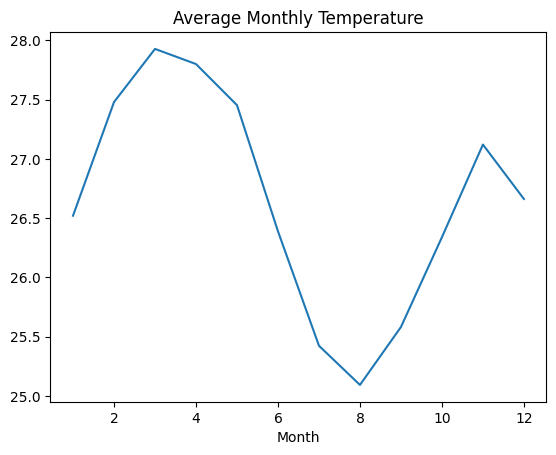

In [7]:
monthly_temp = df.groupby('Month')['T2M'].mean()
monthly_temp.plot()
plt.title('Average Monthly Temperature')
plt.show()

Nigeria has a tropical climate. Temperatures are relatively high year-round, typically ranging between 25–30°C, with slightly cooler periods during the harmattan season (November–February).

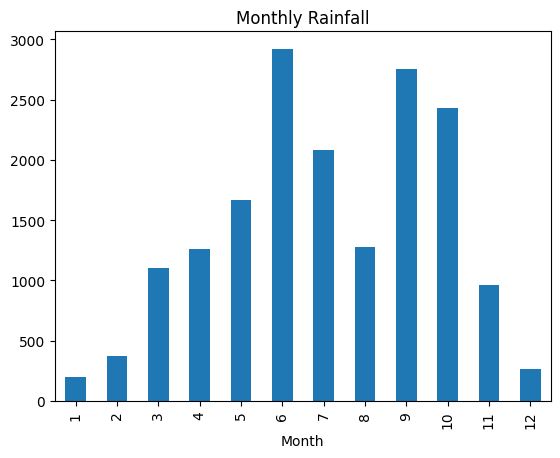

In [8]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
monthly_rain.plot(kind='bar')
plt.title('Monthly Rainfall')
plt.show()

Nigeria experiences a distinct wet season (April–October) and dry season (November–March). Rainfall peaks around July–September, driven by the West African monsoon.

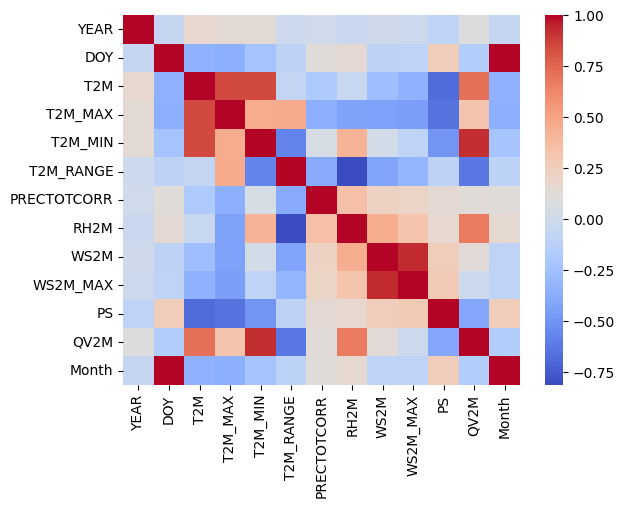

In [9]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

The heatmap shows strong positive correlations between T2M, T2M_MAX, and T2M_MIN. Month correlates with rainfall (PRECTOTCORR), confirming Nigeria's strong seasonal rainfall pattern.

## 7. Export Clean Data
Save the cleaned dataset for use in further analysis.

In [10]:
df.to_csv('../data/nigeria_clean.csv', index=False)